In [138]:
from matplotlib import pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

import torch
import numpy as np
from copy import deepcopy


from torch import nn
from umap import UMAP

from run_sim import Config, run_sim, run_sim_wrapper, create_data
from utils import *
from tqdm import tqdm
from tqdm import tqdm
from utils import *
import matplotlib as mpl
import scipy
from scipy.special import softmax
from functools import reduce
from utils_plot import plot_pca



In [139]:
def calc_h_var(G, D, N, L, sig_X):
    return G**(2*L)*(2*D*sig_X)/(D+N)

In [140]:
C = Config()

C.G = 0.5
C.sig_h_2 = None
# C.gpu_id=1
# C.seed = 1
C.linear_net = True
# C.split_actions = True
# C.allow_backwards = True
C.learning_rate = 0.0001
C.L=1
C.print_progress = True
C.algo_name = 'Adam'
C.loss_fn = nn.MSELoss()
C.length_corridors = [40]*1
# C.input_size = 10
C.max_move = 5
C.hidden_size = 250 # (C.length_corridors[0]+2*C.max_move+1 + 1)*len(C.length_corridors)
C.num_epochs = 1
C.cyclic_corridors = False
C.one_hot_inputs = True
C.one_hot_actions = True
C.scalar_actions = False

In [141]:
data_dict_l = []
for max_move in [1, C.length_corridors[0]//2]: # np.arange(1, C.length_corridors[0], 1):
    C = deepcopy(C)
    C.max_move = max_move
    data_dict = run_sim_wrapper(C)
    data_dict_l.append(data_dict)

Number of samples: 118
Input dimension: 43
Output dimension: 40
Number of actions: 3

Sig_2 of last hidden: 0.0035068767610937357


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 14.32it/s]


Number of samples: 1220
Input dimension: 81
Output dimension: 40
Number of actions: 41

Sig_2 of last hidden: 0.003014312358573079


100%|██████████| 1/1 [00:00<00:00, 15.94it/s]


In [142]:
# for data_dict in data_dict_l:
#     plot_pca(data_dict)

In [143]:
import numpy as np

def nullspace(X, rtol=1e-12):
    """
    Returns an orthonormal basis for Null(X) as a matrix N with shape (d, m),
    where X is (n, d) and m = dim(Null(X)).
    Uses SVD: Null(X) is spanned by right-singular vectors corresponding to
    (near-)zero singular values.
    """
    X = np.asarray(X)
    U, S, Vt = np.linalg.svd(X, full_matrices=True)  # Vt is (d, d)
    # Treat singular values <= tol as zero
    tol = rtol * (S[0] if S.size else 1.0)
    rank = np.sum(S > tol)
    N = Vt[rank:].T  # (d, d-rank)
    return N

def ols_min_norm(X, y):
    """
    Minimum-norm OLS solution w0 = X^+ y.
    Supports y as shape (n,) or (n, k) for multi-output.
    """
    X = np.asarray(X)
    y = np.asarray(y)
    X_pinv = np.linalg.pinv(X)  # Moore–Penrose pseudoinverse
    return X_pinv @ y

def sample_ols_solutions(X, y, n_samples=10, coeff_scale=1.0, rtol=1e-12, rng=None):
    """
    Samples n_samples solutions from the OLS solution set:
        w = w0 + N @ a
    where N spans Null(X) and a is random.

    coeff_scale controls the spread of samples (in coefficient space).
    """
    if rng is None:
        rng = np.random.default_rng()

    X = np.asarray(X)
    y = np.asarray(y)

    w0 = ols_min_norm(X, y)
    N = nullspace(X, rtol=rtol)  # (d, m)

    d = X.shape[1]
    m = N.shape[1]

    samples = []
    for _ in range(n_samples):
        coeff_scale = np.random.uniform(0.1, 10.)
        if m == 0:
            # Unique solution (up to numerical tolerance)
            samples.append(w0.copy())
            continue

        # a has shape (m,) for single-output, (m, k) for multi-output
        if y.ndim == 1:
            a = rng.normal(size=(m,)) * coeff_scale
        else:
            k = y.shape[1]
            a = rng.normal(size=(m, k)) * coeff_scale

        w = w0 + N @ a
        samples.append(w)

    return w0, N, samples

def check_same_fit(X, y, w_list, atol=1e-8):
    """
    Verifies that all sampled solutions produce the same predictions Xw and
    same residual norm (up to tolerance).
    """
    X = np.asarray(X)
    y = np.asarray(y)

    preds0 = X @ w_list[0]
    res0 = y - preds0
    norm0 = np.linalg.norm(res0)

    for i, w in enumerate(w_list[1:], start=1):
        preds = X @ w
        res = y - preds
        if not np.allclose(preds, preds0, atol=atol, rtol=0):
            raise AssertionError(f"Predictions differ at sample {i} with difference {np.linalg.norm(preds-preds0)}")
        if not np.isclose(np.linalg.norm(res), norm0, atol=atol, rtol=0):
            raise AssertionError(f"Residual norm differs at sample {i} with difference {np.linalg.norm(res-res0)}")
    return True

data_dict = data_dict_l[1]
X = data_dict['X'].cpu().numpy()
y = data_dict['y'].cpu().numpy()
loc_y = data_dict['loc_y']

rng = np.random.default_rng(0)

# Use higher precision for all calculations
X64 = np.asarray(X, dtype=np.float64)
y64 = np.asarray(y, dtype=np.float64)

w0, N, samples = sample_ols_solutions(X64, y64, n_samples=5, coeff_scale=0.1, rng=rng)
OLS = np.linalg.pinv(X64.T @ X64, rcond=1e-15) @ X64.T @ y64  # higher precision pseudo-inverse
samples = [OLS] + samples
print("dim Null(X) =", N.shape[1])
print("min-norm w0 shape:", w0.shape)
print("one sample w shape:", samples[0].shape)

# Verify all sampled solutions fit identically on training data using high precision
check_same_fit(X64, y64, samples, atol=1e-12)
print("All sampled solutions have identical training predictions/residual norm (within tolerance).")


dim Null(X) = 1
min-norm w0 shape: (81, 40)
one sample w shape: (81, 40)
All sampled solutions have identical training predictions/residual norm (within tolerance).


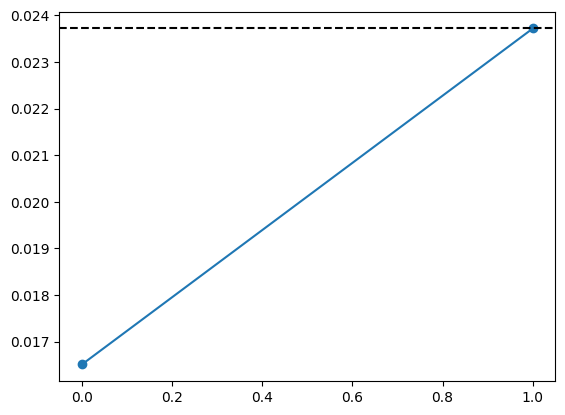

In [144]:
mse_l = []
for data_dict in data_dict_l:
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    OLS = np.linalg.pinv(X.T @ X) @ X.T @ y
    y_hat = X@OLS
    mse = ((y - y_hat)**2).mean()
    mse_l.append(mse)
plt.plot(mse_l, marker='o')
plt.axhline(mse_l[len(mse_l)//2], c='k', ls='--')

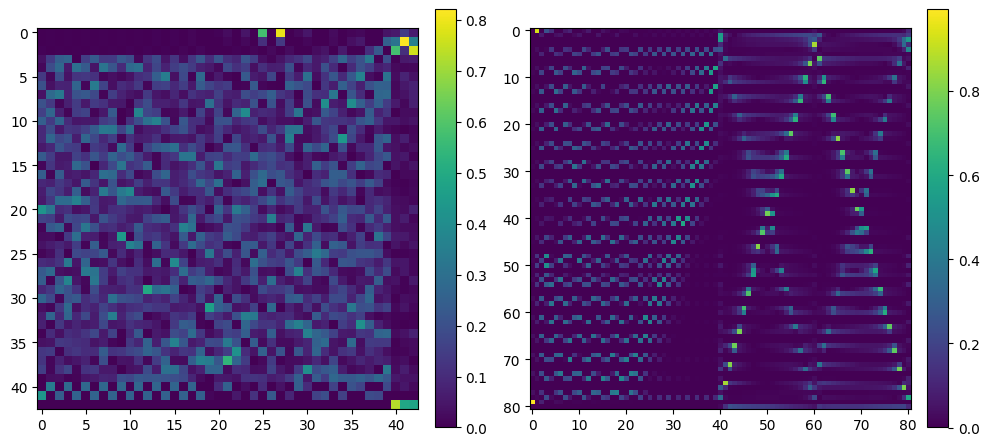

In [147]:
fig, axs = plt.subplots(1,2,figsize=(10,5))
# data_dict = data_dict_l[1]
for i, data_dict in enumerate(data_dict_l):
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    loc_X = data_dict['loc_X']
    action_taken = data_dict['action_taken']
    C = data_dict['C']
    length = C.length_corridors[0]
    A = C.max_move
    X_p = (np.linalg.pinv(X.T @ X) @ X.T)
    Ux, Sx, Vx = np.linalg.svd(X)
    X_p2 = Ux[:,[-1]] @ Vx[[-1],:]
    vx = Vx[[-1], :].T 
    OLS = np.linalg.pinv(X.T @ X) @ X.T @ y
    U, S, V = np.linalg.svd(OLS)

    y_hat = X@OLS

    # i = np.where((loc_X==9)&(action_taken==0))[0][0]
    # plt.figure(figsize=(10,10))
    # plt.plot(y[i].T, marker = 'o', ls='--')
    # plt.plot(y_hat[i].T, marker = 'o')
    overlaps = abs(Vx@U)
    # Step 1: Flatten + argsort descending
    flat_sorted_indices = np.argsort(overlaps.ravel())[::-1]
    # Step 2: Convert back to 2D indices
    # rows, cols = np.unravel_index(flat_sorted_indices, overlaps.shape)
    # axs[i].plot(Vx[rows[0], :], label=f'X {rows[0]}')
    # axs[i].plot(U[:, cols[0]], label=f'OLS {cols[0]}')
    # axs[i].legend()
    im = axs[i].imshow(abs(Vx@U))
    fig.colorbar(im, ax=axs[i], fraction=0.05, pad=0.04)
plt.tight_layout()

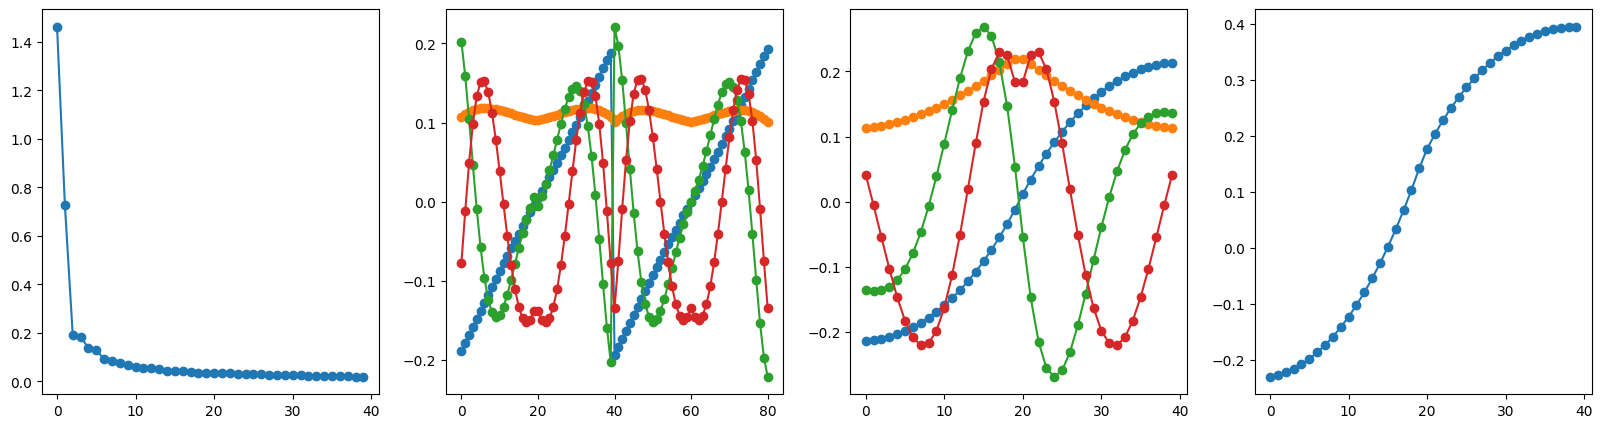

In [146]:
U, S, V = np.linalg.svd(OLS)
fig, axs = plt.subplots(1,4,figsize=(20,5))
axs[0].plot(S, marker = 'o')
for i in range(4):
    axs[1].plot(U[:,i], marker = 'o')
    axs[2].plot(V[i,:], marker = 'o')
axs[3].plot(V[0,:]*S[0] + V[1,:]*S[1], marker = 'o')


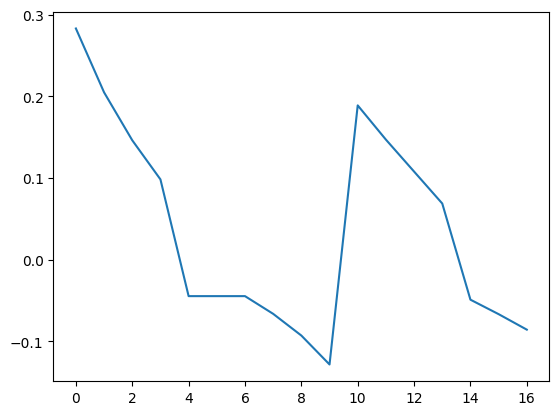

In [96]:
plt.plot(OLS[:,0])

Text(0.5, 1.0, '(103, 100)')

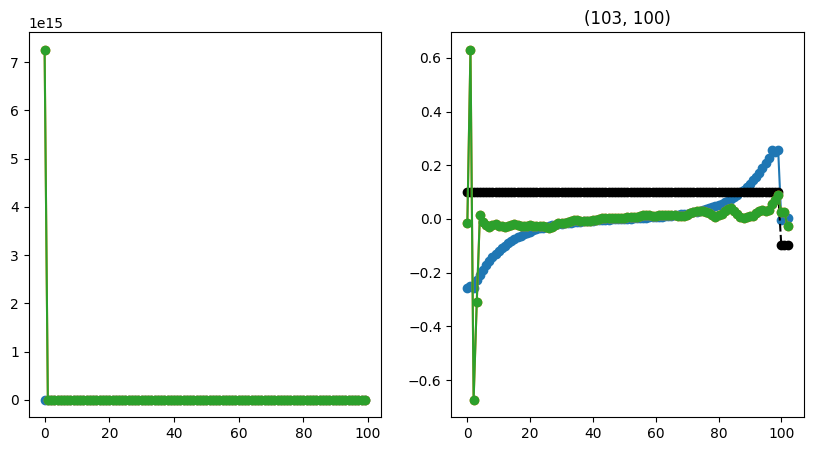

In [228]:
data_dict = data_dict_l[0]
X = data_dict['X'].cpu().numpy()
y = data_dict['y'].cpu().numpy()
X_p = (np.linalg.pinv(X.T @ X) @ X.T)
Ux, Sx, Vx = np.linalg.svd(X)
X_p2 = Ux[:,[-1]] @ Vx[[-1],:]
vx = Vx[[-1], :].T 
OLS = np.linalg.pinv(X.T @ X) @ X.T @ y

U, S, V = np.linalg.svd(OLS)
fig, axs = plt.subplots(1,2,figsize=(10,5))
axs[0].plot(S, marker='o')
axs[1].plot(U[:,0], marker = 'o')
axs[1].plot(vx, marker = 'o', ls='--', c='k')
for _ in range(2):
    u = np.random.randn(y.shape[1], 1) * np.random.randn()*0.5
    vec = np.concatenate([np.linspace(-1,1,y.shape[1]), np.linspace(-.1,.1,3)])[:, None]
    u = -OLS.T@vec / (vec.T@vx)
    OLS_p = OLS + vx @ u.T
    Up, Sp, Vp = np.linalg.svd(OLS_p)
    axs[0].plot(Sp, marker='o')
    axs[1].plot(Up[:,-4], marker = 'o')
plt.title(OLS.shape)

In [ ]:
u = torch.nn.Parameter(torch.randn(y.shape[1], 1) * 0.5)
v_star = 

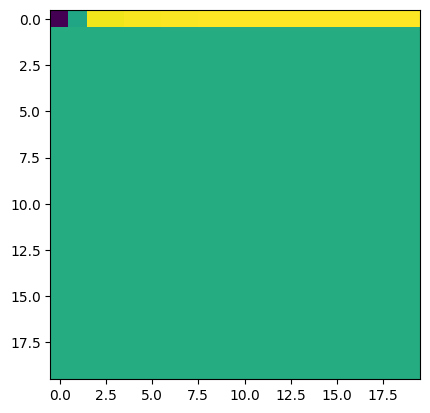

In [168]:
plt.imshow(M.real)

c:\Users\avivra\Desktop\cursor_projects\RepresentationShaping\.venv\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\avivra\Desktop\cursor_projects\RepresentationShaping\.venv\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


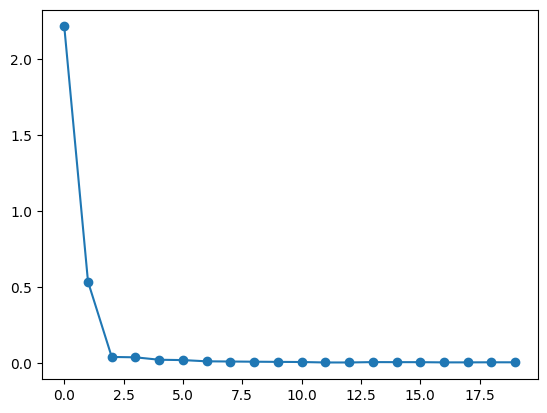

In [176]:
plt.plot(mu,marker = 'o')

Generating 20x20 random matrix...


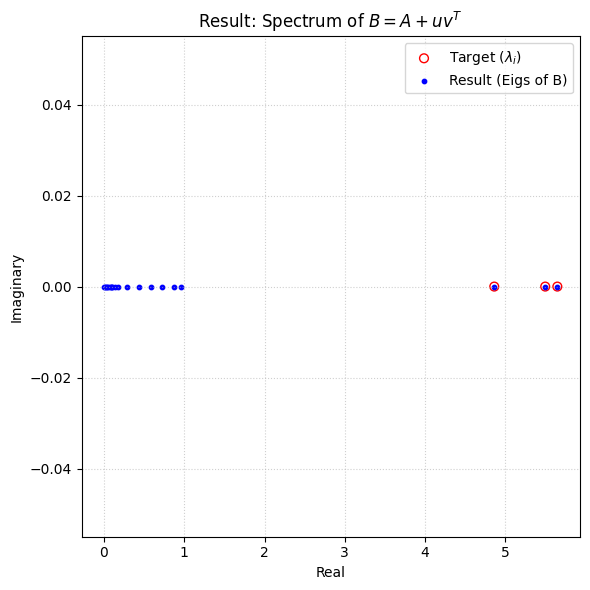

In [202]:
import numpy as np
import matplotlib.pyplot as plt

N = OLS.shape[1]
np.random.seed(42)

print(f"Generating {N}x{N} random matrix...")
A = np.asarray(OLS.T, dtype=np.complex128) @ np.asarray(OLS, dtype=np.complex128)

# Get the original eigenvalues (high precision)
eigvals_A = np.linalg.eigvals(A.astype(np.complex128))

t = np.linspace(0.1, 1, N, dtype=np.float64)
target_eigvals = 5 + np.random.randn(3)

mu, P = np.linalg.eig(A.astype(np.complex128))
P = P.astype(np.complex128)
P_inv = np.linalg.inv(P)
lambda_l = target_eigvals
n_targets = len(lambda_l)
D = np.diag(mu)
M = np.zeros([n_targets, N], dtype=np.complex128)
v_tilda = np.ones([N, 1], dtype=np.complex128)
for i in range(n_targets):
    for j in range(N):
        M[i, j] = 1 / (lambda_l[i] - mu[j])

u_tilda = np.linalg.pinv(M) @ np.ones([n_targets, 1], dtype=np.complex128)
u = P @ u_tilda
v = P_inv.T @ np.ones([N, 1], dtype=np.complex128)
B = A + u @ v.T

eigvals_B = np.linalg.eigvals(B.astype(np.complex128))
eigvals_B = np.sort_complex(eigvals_B)

plt.figure(figsize=(6, 6))
plt.scatter(target_eigvals.real, target_eigvals.imag, s=40,
            facecolors='none', edgecolors='r', label="Target ($\lambda_i$)")
plt.scatter(eigvals_B.real, eigvals_B.imag, s=10,
            c='b', label="Result (Eigs of B)")
# plt.gca().set_aspect('equal')
plt.title("Result: Spectrum of $B = A + uv^T$")
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

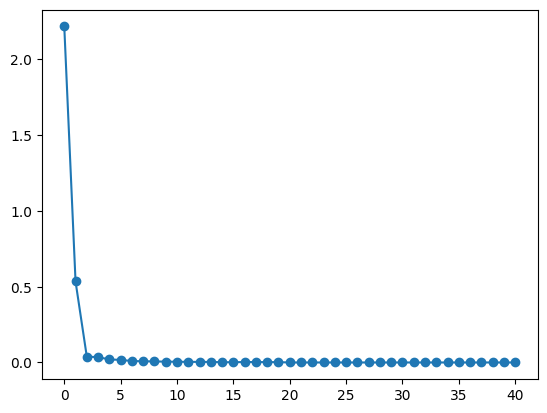

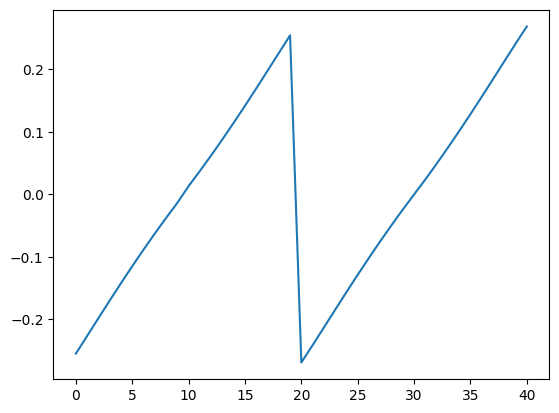

In [115]:
M = OLS@OLS.T
eigs, eigs_v = np.linalg.eig(M)
plt.plot(eigs, marker='o')
plt.show()
plt.plot(eigs_v[:,0])

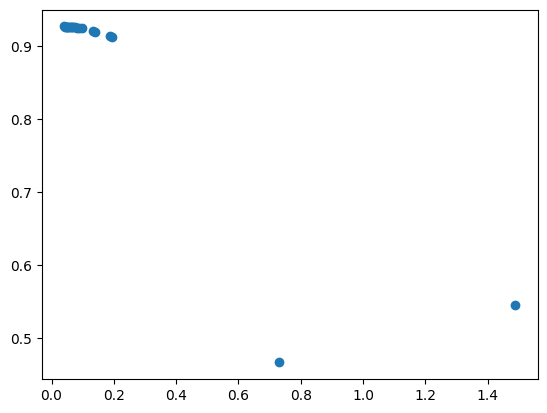

In [127]:
U, S, V = np.linalg.svd(OLS)
MSE = np.linalg.norm(y - X@OLS)
MSE_l = []
for i in range(min(OLS.shape)):
    MSE_l.append(np.linalg.norm(y - S[i]*X@U[:,[i]]@V[[i],:]) - MSE)
plt.scatter(S, MSE_l)
plt.show()


In [69]:
for data_dict in data_dict_l:
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    loc_y = data_dict['loc_y']

    rng = np.random.default_rng(0)

    # Use higher precision for all calculations
    X64 = np.asarray(X, dtype=np.float64)
    y64 = np.asarray(y, dtype=np.float64)

    w0, N, samples = sample_ols_solutions(X64, y64, n_samples=10, coeff_scale=1., rng=rng)
    OLS = np.linalg.pinv(X64.T @ X64, rcond=1e-15) @ X64.T @ y64  # higher precision pseudo-inverse
    samples = [OLS] + samples
    print("dim Null(X) =", N.shape[1])
    print("min-norm w0 shape:", w0.shape)
    print("one sample w shape:", samples[0].shape)

    # Verify all sampled solutions fit identically on training data using high precision
    check_same_fit(X64, y64, samples, atol=1e-12)
    print("All sampled solutions have identical training predictions/residual norm (within tolerance).")

    fig, axs_all = plt.subplots(4, len(samples), figsize=(len(samples)*3, 3*4))
    axs = axs_all[0]
    for i, w in enumerate(samples):
        axs[i].imshow(w)
        axs[i].set_title(f"Sample {i}")

    axs = axs_all[1]
    for i, w in enumerate(samples):
        U, S, V = np.linalg.svd(w)
        axs[i].plot(S, marker='o')
        axs[i].set_title(f"Sample {i}")

    axs = axs_all[2]
    for i, w in enumerate(samples):
        U, S, V = np.linalg.svd(w)
        axs[i].plot(U[:,0], marker='o')
        axs[i].plot(U[:,1], marker='o')
        axs[i].set_title(f"Sample {i}")

    axs = axs_all[3]
    for i, w in enumerate(samples):
        U, S, V = np.linalg.svd(w)
        hidden = X @ U[:,:2]
        axs[i].scatter(hidden[:,0], hidden[:,1], c=loc_y, cmap='coolwarm')
        axs[i].set_title(f"Sample {i}")
        axs[i].axis('equal')
    plt.tight_layout()
    save_path = f'figures/analyze_OLS/OLS_samples_{data_dict["C"].length_corridors[0]}_{data_dict["C"].max_move}.png'
    fig.savefig(save_path)
    plt.close()
    print(f'Saved to {save_path}')

dim Null(X) = 1
min-norm w0 shape: (23, 20)
one sample w shape: (23, 20)
All sampled solutions have identical training predictions/residual norm (within tolerance).
Saved to figures/analyze_OLS/OLS_samples_20_1.png
dim Null(X) = 1
min-norm w0 shape: (41, 20)
one sample w shape: (41, 20)
All sampled solutions have identical training predictions/residual norm (within tolerance).
Saved to figures/analyze_OLS/OLS_samples_20_10.png
dim Null(X) = 1
min-norm w0 shape: (59, 20)
one sample w shape: (59, 20)
All sampled solutions have identical training predictions/residual norm (within tolerance).
Saved to figures/analyze_OLS/OLS_samples_20_19.png


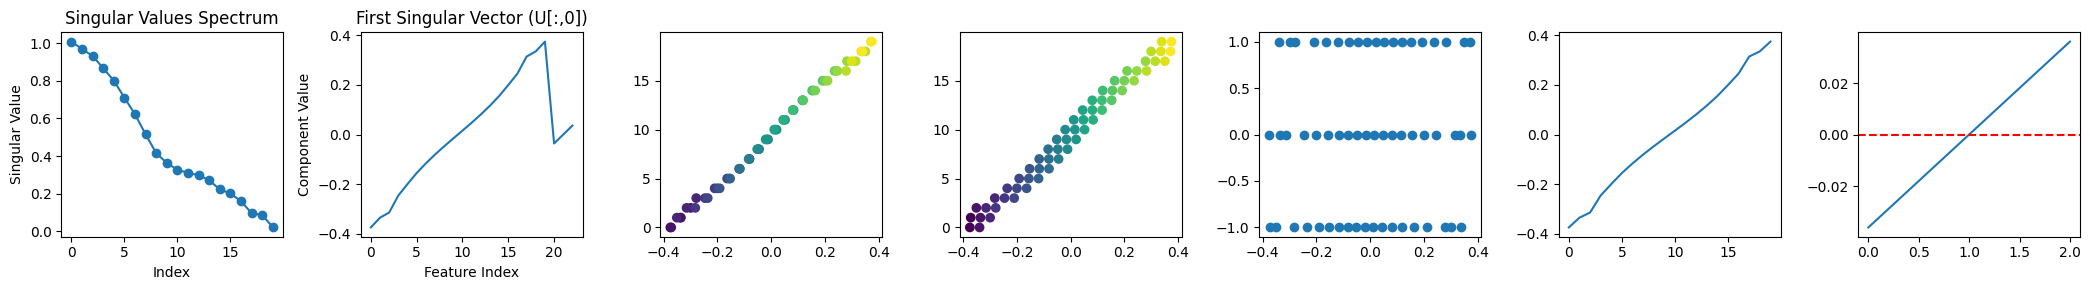

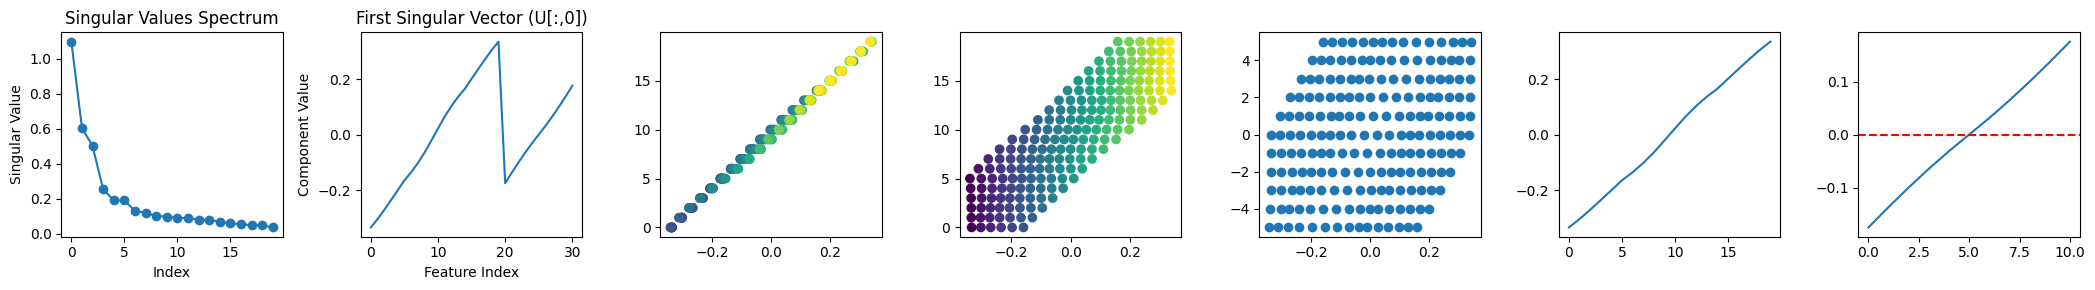

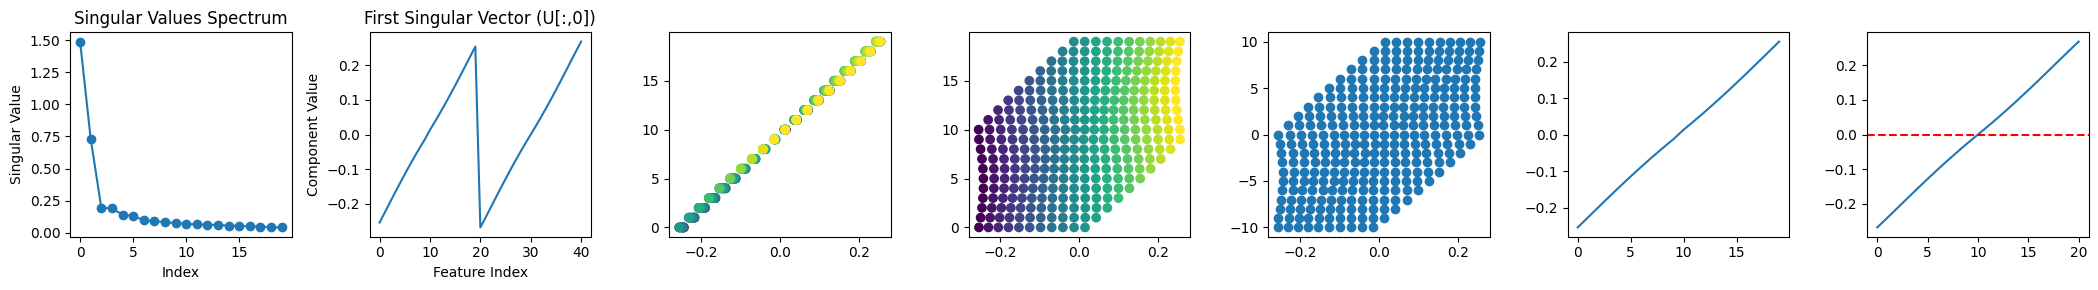

In [29]:
for data_dict in data_dict_l:
    X = data_dict['X']
    y = data_dict['y']
    loc_y = data_dict['loc_y']
    loc_x = data_dict['loc_X']
    action_taken = data_dict['action_taken']
    env_size = data_dict['C'].length_corridors[0]
    N = X.shape[0]

    XT_X = X.T @ X /N
    XT_y = X.T @ y /N
    S = torch.linalg.pinv(XT_X) @ XT_y  

    cond = abs(action_taken) <= 1

    # Singular value decomposition
    U, s, Vt = torch.linalg.svd(S)
    s = s.cpu().numpy()
    U = U.cpu().numpy()
    
    # Plot singular values spectrum
    plt.figure(figsize=(21, 3))
    n = 7
    plt.subplot(1, n, 1)
    plt.plot(s, 'o-')
    plt.title('Singular Values Spectrum')
    plt.xlabel('Index')
    plt.ylabel('Singular Value')

    # Plot first singular vector
    plt.subplot(1, n, 2)
    plt.plot(U[:, 0])
    # plt.plot(U[:, 1], '-')
    plt.title('First Singular Vector (U[:,0])')
    plt.xlabel('Feature Index')
    plt.ylabel('Component Value')

    plt.subplot(1, n, 3)
    cond = abs(action_taken) <= 1000
    X = X.cpu().numpy()[cond]
    y = y.cpu().numpy()[cond]
    # plt.scatter(X@U[:, 0], X@U[:, 1], c=loc_y[cond])
    # plt.axis('equal')
    plt.scatter(X@U[:, 0], loc_y[cond], c=loc_x[cond])
    # plt.scatter(X@U[:, 1], loc_y[cond])
    # plt.scatter(X@U[:, 2], loc_y[cond])

    plt.subplot(1, n, 4)
    # plt.scatter(X@U[:, 0], X@U[:, 1], c=loc_y[cond])
    # plt.axis('equal')
    plt.scatter(X@U[:, 0], loc_x[cond], c=loc_y[cond])
    # plt.scatter(X@U[:, 1], loc_x[cond])
    # plt.scatter(X@U[:, 2], loc_x[cond])

    plt.subplot(1, n, 5)
    # plt.scatter(X@U[:, 0], X@U[:, 1], c=loc_y[cond])
    # plt.axis('equal')
    plt.scatter(X@U[:, 0], action_taken[cond])
    # plt.scatter(X@U[:, 1], action_taken[cond])
    # plt.scatter(X@U[:, 2], action_taken[cond])

    vecs = []
    vecs_a = []
    for i in np.unique(loc_x):
        vecs.append(X[loc_x==i][0,:env_size])
    for a in np.unique(action_taken):
        vecs_a.append(X[action_taken==a][0,env_size:])
    vecs = np.array(vecs)
    vecs_a = np.array(vecs_a)
    plt.subplot(1, n, 6)
    plt.plot(vecs@U[:env_size, 0])
    plt.subplot(1, n, 7)
    plt.plot(vecs_a@U[env_size:, 0])
    plt.axhline(-(vecs@U[:env_size, 0]).mean(), c='red', ls='--')
    plt.tight_layout()
    plt.show()


/home/avivra/Desktop/project/RepresentationShaping/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/avivra/Desktop/project/RepresentationShaping/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


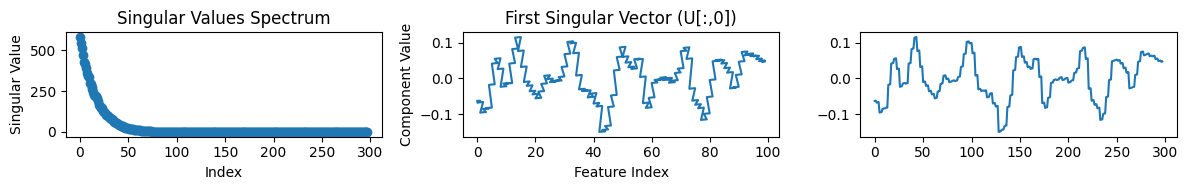

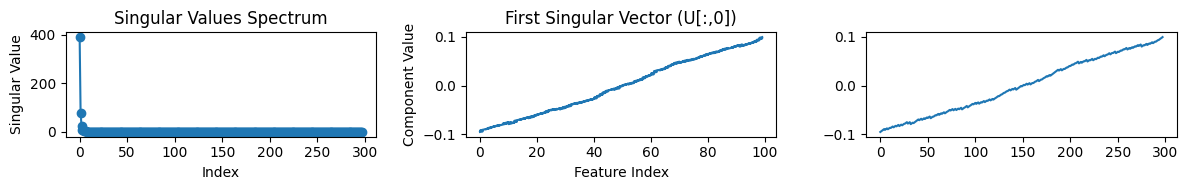

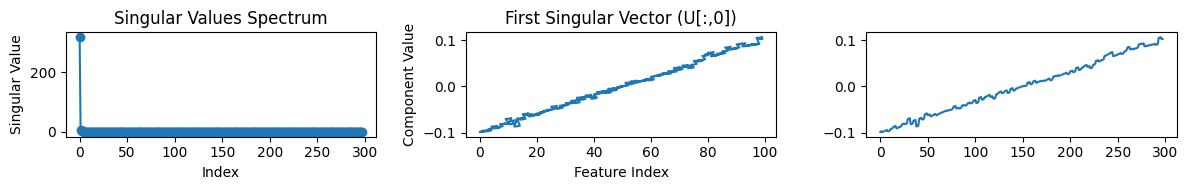

In [8]:
for data_dict in data_dict_l:
    X = data_dict['X']
    y = data_dict['y']
    loc_y = data_dict['loc_y']
    action_taken = data_dict['action_taken']
    N = X.shape[0]

    XT_X = X.T @ X /N
    XT_y = X.T @ y /N
    S = torch.linalg.pinv(XT_X) @ XT_y  

    cond = abs(action_taken) <= 1

    # Singular value decomposition
    # U, s, Vt = torch.linalg.svd(X@S)
    # s = s.cpu().numpy()
    # U = U.cpu().numpy()
    y_hat = X[cond]@S
    y_hat_white = y_hat - y_hat.mean(0, keepdims=True)
    eigs, eigs_v = torch.linalg.eig(y_hat_white@y_hat_white.T)
    eigs = eigs.cpu().numpy()
    eigs_v = eigs_v.cpu().numpy()
    # Plot singular values spectrum
    plt.figure(figsize=(12, 2))
    plt.subplot(1, 3, 1)
    plt.plot(eigs, 'o-')
    plt.title('Singular Values Spectrum')
    plt.xlabel('Index')
    plt.ylabel('Singular Value')

    # Plot first singular vector
    plt.subplot(1, 3, 2)
    plt.plot(loc_y[cond], eigs_v[:, 0])
    # plt.plot(U[:, 1], '-')
    plt.title('First Singular Vector (U[:,0])')
    plt.xlabel('Feature Index')
    plt.ylabel('Component Value')
    
    plt.subplot(1, 3, 3)
    plt.plot(eigs_v[:, 0])

    plt.tight_layout()
    plt.show()


In [9]:

X = data_dict['X']
y = data_dict['y']
loc_y = data_dict['loc_y']
action_taken = data_dict['action_taken']
N = X.shape[0]

XT_X = X.T @ X /N
XT_y = X.T @ y /N
W = torch.linalg.pinv(XT_X) @ XT_y  

XW = (X@W).cpu().numpy()
y = y.cpu().numpy()


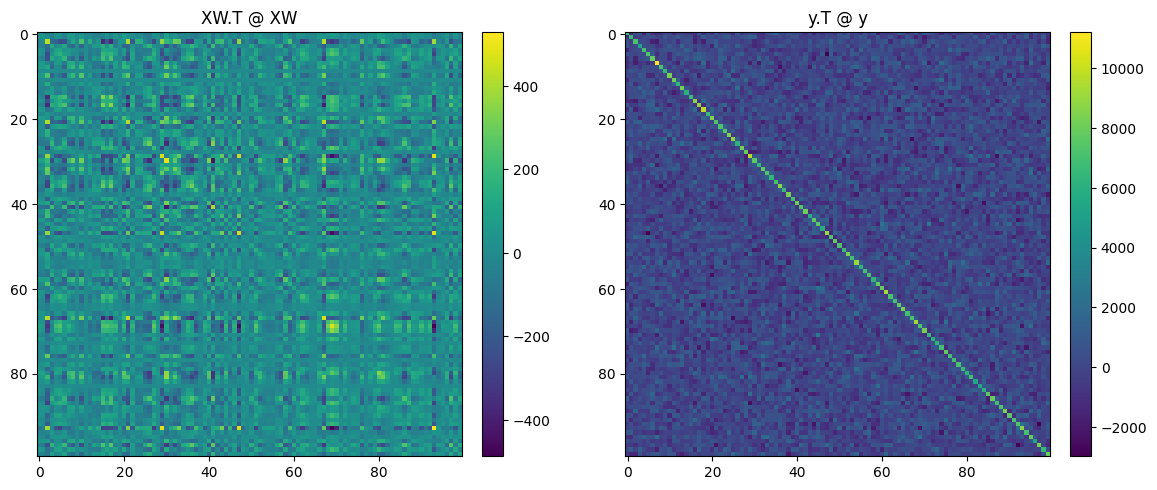

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

im0 = axs[0].imshow(XW.T @ XW)
axs[0].set_title("XW.T @ XW")
plt.colorbar(im0, ax=axs[0], fraction=0.05, pad=0.04)

im1 = axs[1].imshow(y.T @ y)
axs[1].set_title("y.T @ y")
plt.colorbar(im1, ax=axs[1], fraction=0.05, pad=0.04)

plt.tight_layout()
plt.show()


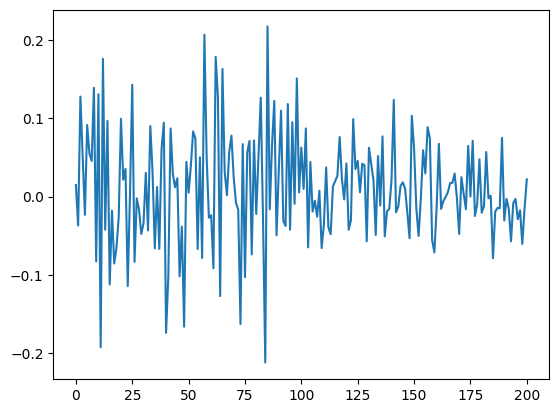

In [11]:
plt.plot(U[:,0])

<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:27: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1257928/509774222.py:27: SyntaxWarning: invalid escape sequence '\l'
  axs[1].set_title("$\left(X^T X\\right)^{-1}$")


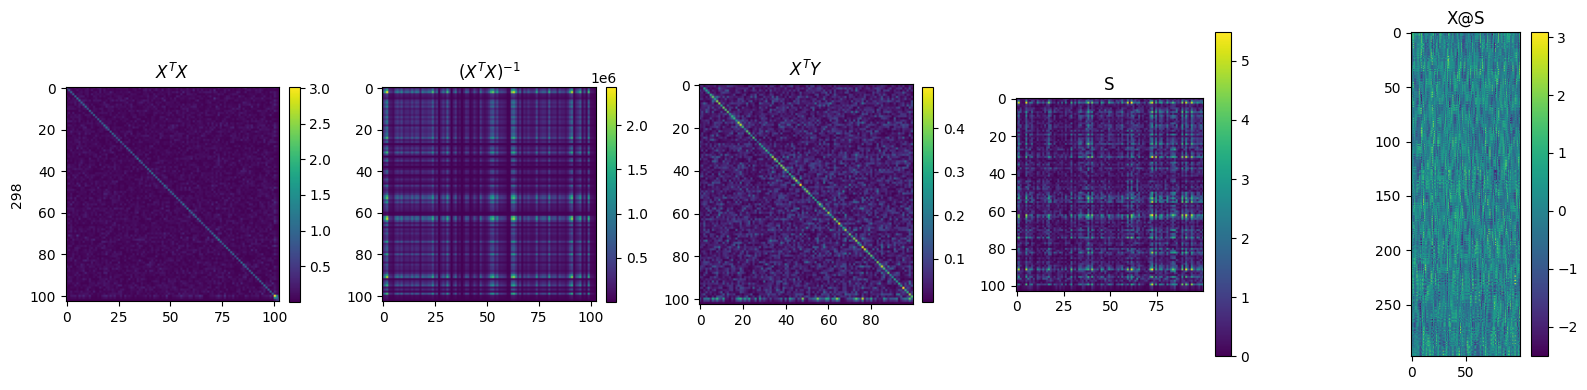

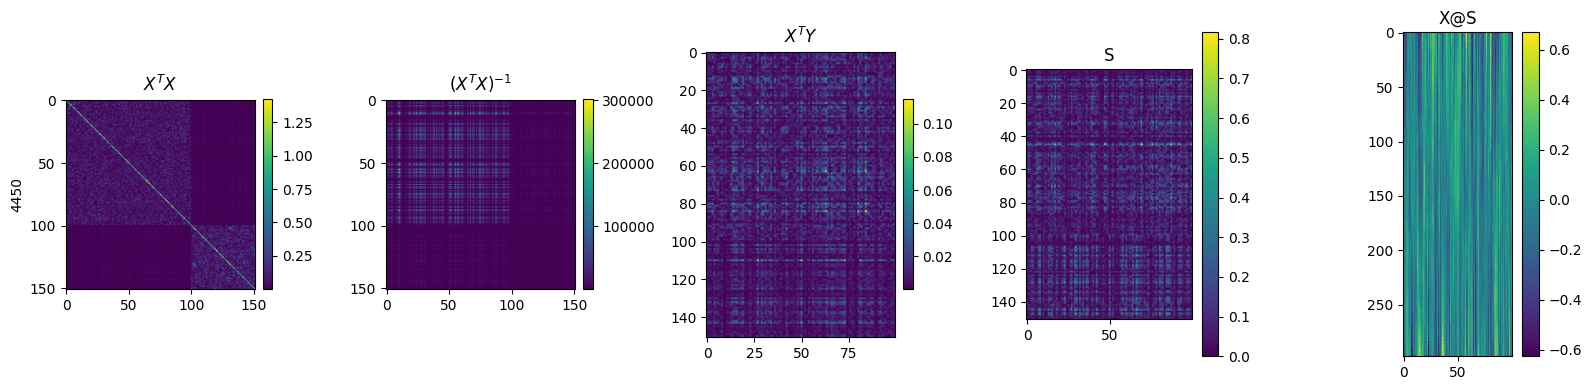

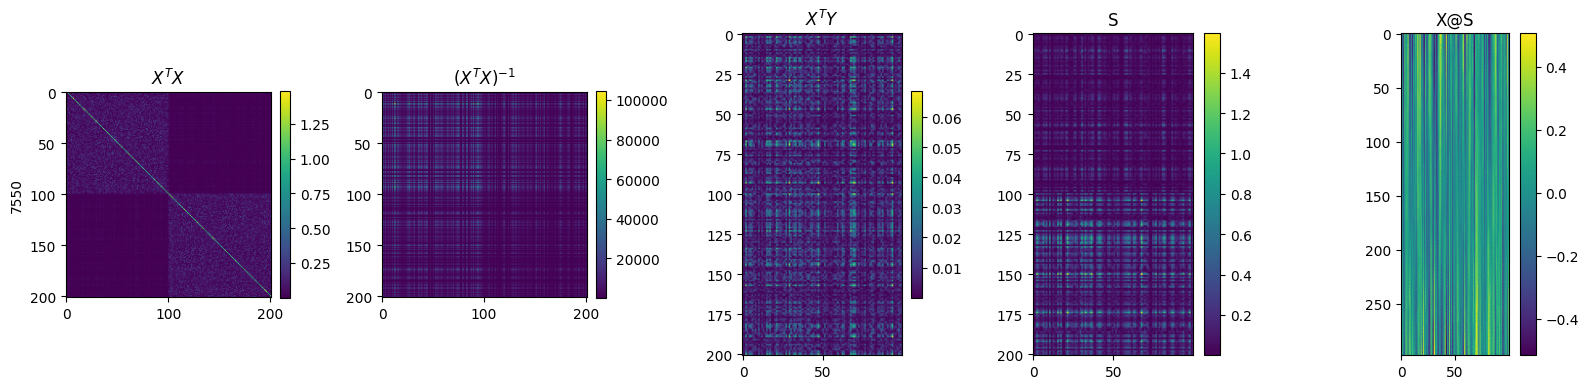

In [12]:
for data_dict in data_dict_l:
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    action_taken = data_dict['action_taken']
    loc_y = data_dict['loc_y']
    N = X.shape[0]

    XT_X = X.T @ X /N
    XT_y = X.T @ y /N
    S = np.linalg.pinv(XT_X) @ XT_y  
    # Visualize the key OLS matrices as images

    fig, axs = plt.subplots(1, 5, figsize=(16, 4))

    # 1. X^T X
    im0 = axs[0].imshow(abs(XT_X))
    axs[0].set_title("$X^T X$")
    plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
    axs[0].set_ylabel(N)

    # 2. inv(X^T X) X^T y
    # This is S as computed previously, but let's show the intermediate inv(X^T X) @ XT_y too
    XTX_inv = np.linalg.pinv(XT_X)
    XTX_inv_XTy = XTX_inv @ XT_y

    im1 = axs[1].imshow(abs(XTX_inv))
    axs[1].set_title("$\left(X^T X\\right)^{-1}$")
    plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)


    im1 = axs[2].imshow(abs(XT_y))
    axs[2].set_title("$X^TY$")
    plt.colorbar(im1, ax=axs[2], fraction=0.046, pad=0.04)

    # 3. S
    im2 = axs[3].imshow(abs(S))
    axs[3].set_title("S")
    plt.colorbar(im2, ax=axs[3])

    cond = abs(action_taken) <= 1
    im = axs[4].imshow(X[cond][loc_y[cond].argsort()]@S)
    axs[4].set_title("X@S")
    plt.colorbar(im, ax=axs[4])


    plt.tight_layout()
    plt.show()


S = 100, A = 50


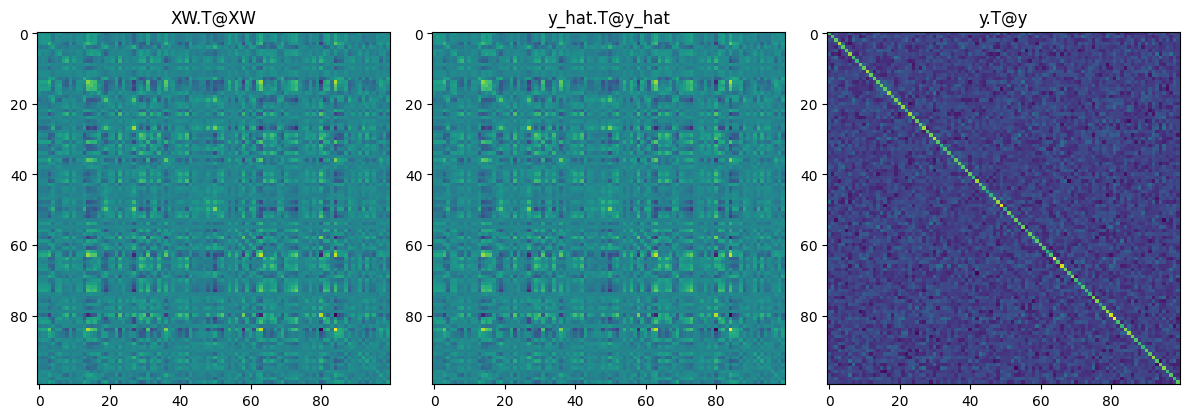

In [42]:
data_dict = data_dict_l[1]
print(f'S = {data_dict["C"].length_corridors[0]}, A = {data_dict["C"].max_move}')
X = data_dict['X']
y = data_dict['y']
loc_y = data_dict['loc_y']
loc_x = data_dict['loc_X']
action_taken = data_dict['action_taken']
env_size = data_dict['C'].length_corridors[0]
N = X.shape[0]

XT_X = X.T @ X /N
XT_y = X.T @ y /N
W = torch.linalg.pinv(XT_X) @ XT_y  

XW = (X@W).cpu().numpy()
y = y.cpu().numpy()



X = X.cpu().numpy()
y = y
Ux, Sx, Vx = np.linalg.svd(X, full_matrices=False)
Uy, Sy, Vy = np.linalg.svd(y, full_matrices=False)

y_hat = Ux@Ux.T@Uy@np.diag(Sy)@Vy

XT_X = X.T @ X
XT_y = X.T @ y
W = np.linalg.pinv(XT_X) @ XT_y  

fig, axs = plt.subplots(1, 3, figsize=(12, 5))
axs[0].imshow(XW.T@XW)
axs[0].set_title("XW.T@XW")
axs[1].imshow(y_hat.T@y_hat)
axs[1].set_title("y_hat.T@y_hat")
axs[2].imshow(y.T@y)
axs[2].set_title("y.T@y")
plt.tight_layout()
plt.show()

In [47]:
eigs, eigs_v = np.linalg.eig(y_hat.T@y_hat)

In [48]:
eigs_v.shape

(100, 100)

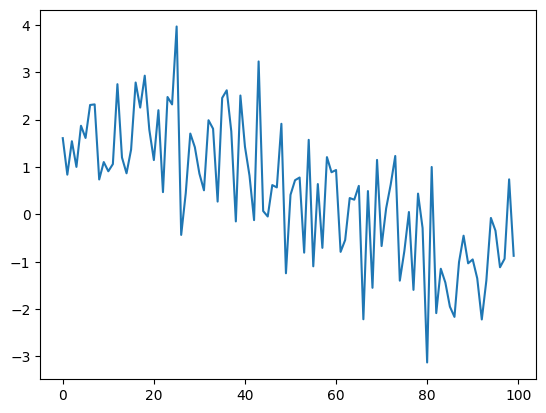

In [45]:
vecs = []
for i in np.unique(loc_x):
    vecs.append(X[loc_x==i][0,:env_size])
vecs = np.array(vecs)
plt.plot(vecs@U[:env_size, 0])
plt.show()


In [33]:
y_y = y@y.T
y_hat_y_hat = Ux@Ux.T@Uy@np.diag(Sy**2)@Uy.T@Ux@Ux.T

y_pca = np.linalg.eig(y_y)[1]
y_hat_pca = np.linalg.eig(y_hat_y_hat)[1]

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
cond = abs(action_taken) <= 1
sc0 = axs[0].scatter(y_pca[cond, 0], y_pca[cond, 1], c=loc_y[cond], cmap='viridis', s=5)
axs[0].set_title('PCA of y')
plt.colorbar(sc0, ax=axs[0])

sc1 = axs[1].scatter(y_hat_pca[cond, 0], y_hat_pca[cond, 1], c=loc_y[cond], cmap='viridis', s=5)
axs[1].set_title('PCA of y_hat')
plt.colorbar(sc1, ax=axs[1])

plt.tight_layout()
plt.show()


KeyboardInterrupt: 

In [ ]:
C.print_progress = False
N = C.length_corridors[0]
n = int(np.sqrt(N))
fig, axs = plt.subplots(n, n, figsize=(n*3, n*3))
for max_move, ax in zip(range(1,N), axs.flatten()):
    C.max_move = max_move
    data_dict = run_sim_wrapper(C)
    data_dict_l.append(data_dict)
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()

    XT_X = X.T @ X
    XT_y = X.T @ y
    S = np.linalg.pinv(XT_X) @ XT_y  
    ax.imshow(S)

In [ ]:
C.print_progress = False
N = C.length_corridors[0]
n = int(np.sqrt(N))
fig, axs = plt.subplots(n, n, figsize=(n*3, n*3))
for max_move, ax in zip(range(1,N), axs.flatten()):
    C.max_move = max_move
    data_dict = run_sim_wrapper(C)
    data_dict_l.append(data_dict)
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()

    XT_X = X.T @ X
    XT_y = X.T @ y
    S = np.linalg.pinv(XT_X) @ XT_y  
    U, S, Vt = np.linalg.svd(S)
    ax.plot(U[:,:2])

In [ ]:
C.print_progress = False
N = C.length_corridors[0]
fig, ax = plt.subplots(1, 1, figsize=(20, 5))
for max_move in tqdm(range(1,N)):
    C.max_move = max_move
    data_dict = run_sim_wrapper(C)
    data_dict_l.append(data_dict)
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()

    XT_X = X.T @ X
    XT_y = X.T @ y
    S = np.linalg.pinv(XT_X) @ XT_y  
    U, S, Vt = np.linalg.svd(S)
    plt.plot(np.arange(1, S.shape[0]+1), S, lw=0.5, marker='o', markersize=1)
plt.xscale('log')

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def get_r2(y):
    x = np.arange(y.shape[0]).reshape(-1, 1)
    # Prepare the data for linear regression
    lr = LinearRegression()
    lr.fit(x, y)
    y_pred = lr.predict(x)
    r2 = r2_score(y, y_pred)
    return r2

In [ ]:
C.print_progress = False
N = C.length_corridors[0]
PR_l = []
eigv_score_l = []
for max_move in tqdm(range(1,N)):
    C.max_move = max_move
    data_dict = run_sim_wrapper(C)
    data_dict_l.append(data_dict)
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()

    XT_X = X.T @ X
    XT_y = X.T @ y
    S = np.linalg.pinv(XT_X) @ XT_y  
    U, S, Vt = np.linalg.svd(S)
    eigv_score_l.append(1-max(get_r2(U[:-1,0]), get_r2(U[:-1,1])))
    PR_l.append(np.sum(S)**2/np.sum(S**2))


In [ ]:
plt.scatter(PR_l, eigv_score_l, c=np.arange(1,N))
plt.scatter(PR_l[N//2], eigv_score_l[N//2], c='red', s=100)
plt.colorbar()
plt.yscale('log')
plt.xscale('log')
plt.xlabel('PR')
plt.ylabel('Eigv Score')

In [ ]:
plt.plot(PR_l)

step    1 | loss 0.6925 | acc 100.00%
step 4000 | loss 0.0000 | acc 100.00%
step 8000 | loss 0.0000 | acc 100.00%
step 12000 | loss 0.0000 | acc 100.00%
step 16000 | loss 0.0000 | acc 100.00%
step 20000 | loss 0.0000 | acc 100.00%
step 24000 | loss 0.0000 | acc 100.00%
step 28000 | loss 0.0000 | acc 100.00%
step 32000 | loss 0.0000 | acc 100.00%
step 36000 | loss 0.0000 | acc 100.00%
step 40000 | loss 0.0000 | acc 100.00%


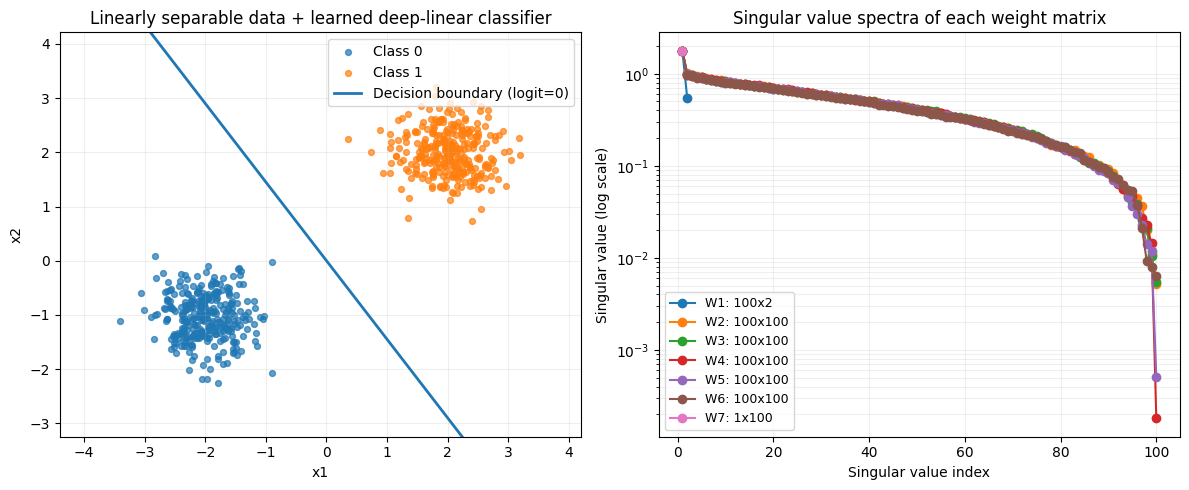

In [78]:
# Deep linear network on a linearly-separable 2-class dataset
# - Generates 2D data from two classes (linearly separable)
# - Trains a deep *linear* network for binary classification
# - Plots: (1) data + learned linear decision boundary, (2) singular value spectra of each weight matrix

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ----------------------------
# Reproducibility
# ----------------------------
seed = 6
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# Generate linearly separable data (2D)
# ----------------------------
N_per_class = 300
N = 2 * N_per_class

# Two Gaussian clouds separated along x-axis
mu_pos = np.array([+2.0, +2.0])
mu_neg = np.array([-2.0, -1.0])
cov = np.array([[0.2, 0.0],
                [0.0, 0.2]])

X_pos = np.random.multivariate_normal(mu_pos, cov, size=N_per_class)
X_neg = np.random.multivariate_normal(mu_neg, cov, size=N_per_class)

X = np.vstack([X_pos, X_neg]).astype(np.float32)
y = np.concatenate([np.ones(N_per_class), np.zeros(N_per_class)]).astype(np.float32)

# Shuffle
perm = np.random.permutation(N)
X = X[perm]
y = y[perm]

X_t = torch.tensor(X, device=device)
y_t = torch.tensor(y, device=device).view(-1, 1)

# ----------------------------
# Deep linear network definition
# ----------------------------
class DeepLinear(nn.Module):
    def __init__(self, dims):
        """
        dims: list like [in_dim, h1, h2, ..., out_dim]
        All layers are Linear with bias=False to keep the whole map purely linear.
        """
        super().__init__()
        layers = []
        for din, dout in zip(dims[:-1], dims[1:]):
            layers.append(nn.Linear(din, dout, bias=False))
        self.layers = nn.ModuleList(layers)

        # A common choice for deep linear nets is small init to avoid immediate saturation in logistic loss
        for layer in self.layers:
            nn.init.normal_(layer.weight, mean=0.0, std=0.05)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)  # no nonlinearity
        return x

# Architecture: deep linear map R^2 -> R^1 through multiple hidden linear layers
h_s = 100
dims = [2, h_s, h_s, h_s, h_s, h_s, h_s, 1]
model = DeepLinear(dims).to(device)

# ----------------------------
# Training setup
# ----------------------------
lr = 5e-2
weight_decay = 0.0  # keep 0 to observe implicit bias in deep linear optimization
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)

# Use BCE with logits (more stable than sigmoid + BCE)
def loss_fn(logits, targets):
    return F.binary_cross_entropy_with_logits(logits, targets)

# ----------------------------
# Train
# ----------------------------
steps = 40000
print_every = 4000

model.train()
for step in range(1, steps + 1):
    optimizer.zero_grad(set_to_none=True)

    logits = model(X_t)
    loss = loss_fn(logits, y_t)

    loss.backward()
    optimizer.step()

    if step % print_every == 0 or step == 1:
        with torch.no_grad():
            preds = (torch.sigmoid(logits) > 0.5).float()
            acc = (preds.eq(y_t)).float().mean().item()
        print(f"step {step:4d} | loss {loss.item():.4f} | acc {acc*100:.2f}%")

# ----------------------------
# Compute effective classifier (collapse deep linear layers into one matrix)
# For bias=False everywhere: f(x) = x @ W_eff^T where W_eff is 1x2
# ----------------------------
model.eval()
with torch.no_grad():
    W_eff = model.layers[-1].weight.detach().clone()  # shape [1, d_last]
    for layer in reversed(model.layers[:-1]):
        W_eff = W_eff @ layer.weight.detach().clone()  # (1 x next) @ (next x prev) => (1 x prev)
    # Now W_eff shape should be [1, 2]
    W_eff_np = W_eff.cpu().numpy().reshape(-1)  # (2,)

# Decision boundary: W_eff[0]*x + W_eff[1]*y = 0  (threshold at logit=0)
# (If you want threshold at 0.5 prob, that's also logit=0.)
w0, w1 = W_eff_np[0], W_eff_np[1]

# ----------------------------
# Plot data + decision boundary
# ----------------------------
fig = plt.figure(figsize=(12, 5))

ax1 = plt.subplot(1, 2, 1)
ax1.scatter(X[y == 0, 0], X[y == 0, 1], s=18, alpha=0.7, label="Class 0")
ax1.scatter(X[y == 1, 0], X[y == 1, 1], s=18, alpha=0.7, label="Class 1")

# Create a line for boundary within plot bounds
x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

xs = np.linspace(x_min, x_max, 200)
if abs(w1) > 1e-12:
    ys = -(w0 / w1) * xs
    ax1.plot(xs, ys, linewidth=2, label="Decision boundary (logit=0)")
else:
    # Vertical line if w1 ~ 0
    x0 = 0.0 if abs(w0) < 1e-12 else 0.0
    if abs(w0) > 1e-12:
        x0 = 0.0  # boundary w0*x = 0 => x=0
    ax1.axvline(x0, linewidth=2, label="Decision boundary (vertical)")

ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.set_title("Linearly separable data + learned deep-linear classifier")
ax1.legend(loc="best")
ax1.grid(True, alpha=0.2)

# ----------------------------
# Plot singular value spectrum of each weight matrix
# ----------------------------
ax2 = plt.subplot(1, 2, 2)

with torch.no_grad():
    for i, layer in enumerate(model.layers):
        W = layer.weight.detach().cpu().numpy()
        s = np.linalg.svd(W, compute_uv=False)  # singular values sorted desc
        # Plot in log scale for visibility; avoid log(0)
        s_safe = np.maximum(s, 1e-12)
        ax2.plot(np.arange(1, len(s_safe) + 1), s_safe, marker="o", linewidth=1.5, label=f"W{i+1}: {W.shape[0]}x{W.shape[1]}")

ax2.set_yscale("log")
ax2.set_xlabel("Singular value index")
ax2.set_ylabel("Singular value (log scale)")
ax2.set_title("Singular value spectra of each weight matrix")
ax2.grid(True, which="both", alpha=0.2)
ax2.legend(loc="best", fontsize=9)

plt.tight_layout()
plt.show()
